# Here is the repository link used for this project: [github link](https://github.com/WBS-UWG/DataAnalyticsProject01)

## 1. Imports et configuration

In [121]:
from io import StringIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", 50)


## 2. Convert TSV file to CSV


In [122]:
SOURCE_PATH = "datasource/launchlog.tsv"
DATA_PATH = "datasource/launchlog.csv"

with open(SOURCE_PATH, "r", encoding="utf-8") as source_file:
    raw_text = "".join(
        line.lstrip("#")
        for line in source_file
        if not line.startswith("# Updated")
    )

converted = pd.read_csv(
    StringIO(raw_text), sep="\t", dtype="string", low_memory=False, na_values=["-"]
)
converted.columns = converted.columns.str.strip()
converted.to_csv(DATA_PATH, index=False, encoding="utf-8")
print(f"File successfully converted and saved to {DATA_PATH}.")


File successfully converted and saved to datasource/launchlog.csv.


In [ ]:
USED_COLUMNS = ["Launch_Tag", "Name", "Launch_Date", "SatState", "LVState", "LV_Type"]

df = pd.read_csv(
    DATA_PATH,
    usecols=USED_COLUMNS,
    # dtype="string",
    low_memory=False,
    na_values=["-"],
)

df["Launch_Tag"] = df["Launch_Tag"].astype("string")
df["Name"] = df["Name"].astype("string")

df = df[~df["Launch_Tag"].astype(str).str.startswith("#")].copy()

print(f"{len(df):,} lines (objets/satellites) loaded")
df.head()


31,461 lines (objets/satellites) loaded


,Launch_Tag,Launch_Date,Name,SatState,LV_Type,LVState
0,1957 ALP,1957 Oct 4 1928:34,1-y ISZ,SU,Sputnik 8K71PS,SU
1,1957 BET,1957 Nov 3 0230:42,2-y ISZ,SU,Sputnik 8K71PS,SU
2,1957-F01,1957 Dec 6 1644:35,Vanguard,US,Vanguard,US
3,1958 ALP,1958 Feb 1 0347:56,Explorer I,US,Jupiter C,US
4,1958-F01,1958 Feb 5 0733,Vanguard,US,Vanguard,US


## 3. Cleaning the data
The duplicates mainly come from some satellites that blow up and now are multiple pieces in orbit


In [124]:
number_of_satellites_before_cleaning = len(df)

df["Year"] = (
    df["Launch_Date"]
    .astype(str)
    .str.extract(r"((?:19|20)\d{2})")[0]
    .astype("Int64")
)
df = df.dropna(subset=["Year"])
df["Year"] = df["Year"].astype(int)

# Filter to remove satellites maybes launch outside the bounds of dataset (1957-2026)
current_year = 2026
df = df[(df["Year"] >= 1957) & (df["Year"] <= current_year)]

duplicates_removed = df[df.duplicated(subset=["Launch_Tag", "Name"], keep="first")]
df = df.drop_duplicates(subset=["Launch_Tag", "Name"])

print(f"Total lines of data {number_of_satellites_before_cleaning:,}")
print(f"Number of satellites removed after cleaning: {number_of_satellites_before_cleaning - len(df)}")
print("Duplicates removed:")
for index, row in duplicates_removed.iterrows():
    print(f"  - {row['Launch_Tag']} ({row['Name']}) ({row['Launch_Date']})")
print(f"Total lines of data after cleaning: {len(df):,}")

COUNTRY_NAMES = {
    "US": "United States", "SU": "URSS", "RU": "Russia", "CN": "China",
    "F": "France", "J": "Japan", "IN": "India", "UK": "United Kingdom",
    "D": "Germany", "I": "Italy", "CA": "Canada", "IL": "Israël",
    "KR": "South Korea", "ESA": "ESA (Europe)", "EUME": "EUMETSAT",
    "LUX": "Luxembourg", "UAE": "Emirats arabes unis", "IR": "Iran",
    "KP": "North Korea", "BR": "Brazil", "AU": "Australia",
    "PK": "Pakistan", "ID": "Indonesia", "TW": "Taïwan",
}

def readable_country(code):
    return COUNTRY_NAMES.get(code, code)


Total lines of data 31,461
Number of satellites removed after cleaning: 298
Duplicates removed:
  - 1964-F12 (Kosmos) (1964 Oct 23 0730)
  - 1964-F12 (Kosmos) (1964 Oct 23 0730)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-F08 (IDCSP) (1966 Aug 26 1359:56)
  - 1966-099 (OV1-6S balloon?) (1966 Nov  3 1350:42)
  - 1970-041 (Target subsatellite) (1970 Jun  1 1900:00)
  - 1970-041 (Target subsatellite) (1970 Jun  1 1900:00)
  - 1971-012 (S70-4 Drag Sphere) (1971 Feb 17 0352:05)
  - 1971-012 (S70-4 Drag Sphere) (1971 Feb 17 0352:05)
  - 1976-018 (Spuskaemaya Kapsula) (1976 Feb 20 1401:02)
  - 1976-072 (Spuskaemaya Kapsula) (1976 Jul 22 1540:01)
  - 1976-124 (Kosmos-885 SS 18) (1976 Dec 17 1200)
  - 1977-030 (Spuskaemaya Kapsula) (1977 Apr 26 1445)
  - 1977-F02 ([Kosmos]) (

## 4. Evolution of the number of satellites launched over time (sub-question 1)

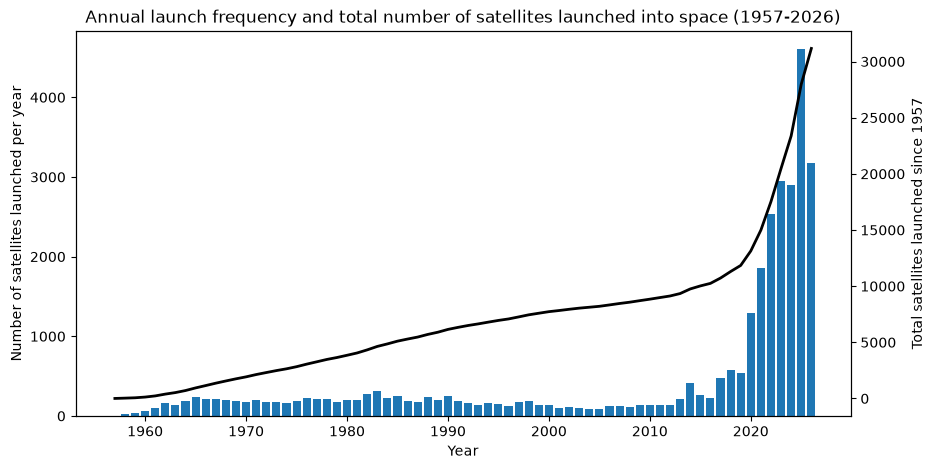

In [125]:
per_year = df.groupby("Year").size().reindex(range(df["Year"].min(), df["Year"].max() + 1), fill_value=0)
cumulative = per_year.cumsum()

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.grid(False)
ax1.bar(per_year.index, per_year.values)
ax1.set_ylabel("Number of satellites launched per year")
ax1.set_xlabel("Year")

ax2 = ax1.twinx()
ax2.plot(cumulative.index, cumulative.values, color="#000000", lw=2)
ax2.set_ylabel("Total satellites launched since 1957")

ax2.grid(False)
plt.title("Annual launch frequency and total number of satellites launched into space (1957-2026)")
plt.show()

This dual-axis chart illustrates the annual satellite launch frequency alongside the cumulative total of satellites launched into space from 1957 to 2026.
For over five decades, between 1957 and the early 2010s, annual launches remained low and relatively stable, generally hovering between 50 and 300 satellites per year, which resulted in a steady, linear growth in the cumulative total.

However, starting around 2015 to 2020, the data reveals an exponential surge in annual activity, rapidly escalating from under 500 satellites per year to a peak of approximately 4,600 satellites per year in 2025.
Concurrently, this recent acceleration causes the cumulative line graph to bend steeply upwards, cumulating a total exceeding 30,000 satellites launched since 1957.

The downturn observed in 2026 is due to incomplete data collection for the current year.

## 5. Which country is the most represented in space? (sub-question 2)


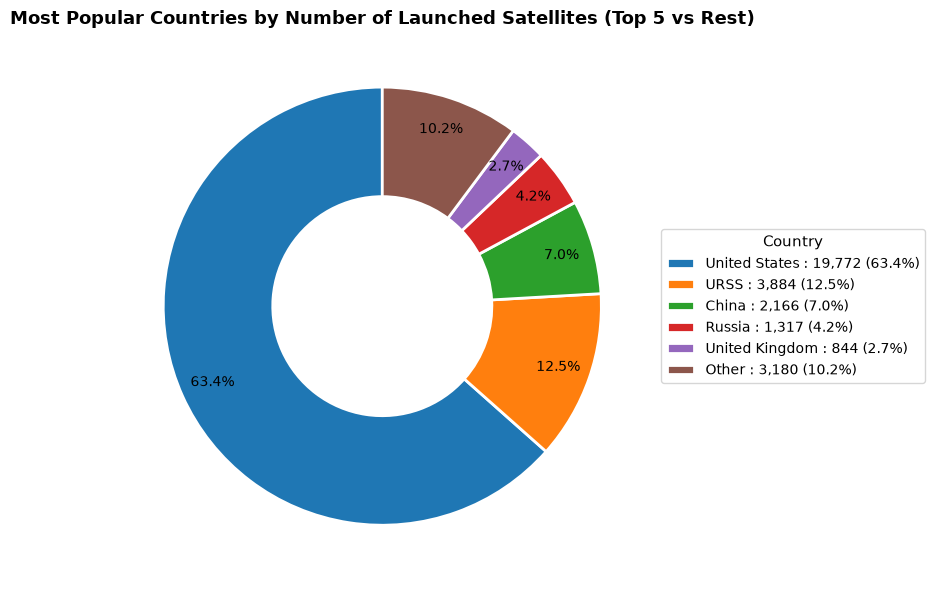

In [126]:
country_counts = df["SatState"].value_counts()

top_5 = country_counts.head(5)
others_sum = country_counts.iloc[5:].sum()

data_to_plot = pd.concat([top_5, pd.Series({"OTHER": others_sum})])

country_names = [
    readable_country(c) if c != "OTHER" else "Other"
    for c in data_to_plot.index
]

fig, ax = plt.subplots(figsize=(9, 6))

wedges, texts, autopcts = ax.pie(
    data_to_plot.values,
    autopct="%1.1f%%",
    pctdistance=0.85,
    startangle=90,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2)
)

total = data_to_plot.sum()
legend_labels = [
    f"{name} : {val:,} ({val/total*100:.1f}%)"
    for name, val in zip(country_names, data_to_plot.values)
]

ax.legend(
    wedges,
    legend_labels,
    title="Country",
    title_fontsize="11",
    loc="center",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=10
)

ax.set_title(
    "Most Popular Countries by Number of Launched Satellites (Top 5 vs Rest)",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()



This donut chart illustrates the distribution of launched satellites by country, comparing the top five nations against the rest of the world.

The United States overwhelmingly dominates global satellite launches, accounting for nearly two-thirds of the total at 63.4% with 19,772 satellites. The former Soviet Union (URSS) holds the second-largest historical share at 12.5% (3,884 satellites), followed by China at 7.0% (2,166 satellites), Russia at 4.2% (1,317 satellites), and the United Kingdom at 2.7% (844 satellites).

All remaining countries combined represent just over a tenth of the total distribution, making up 10.2% with 3,180 satellites. Overall, the chart highlights an extreme concentration in space activity, where the United States alone accounts for more satellites than all other nations combined.

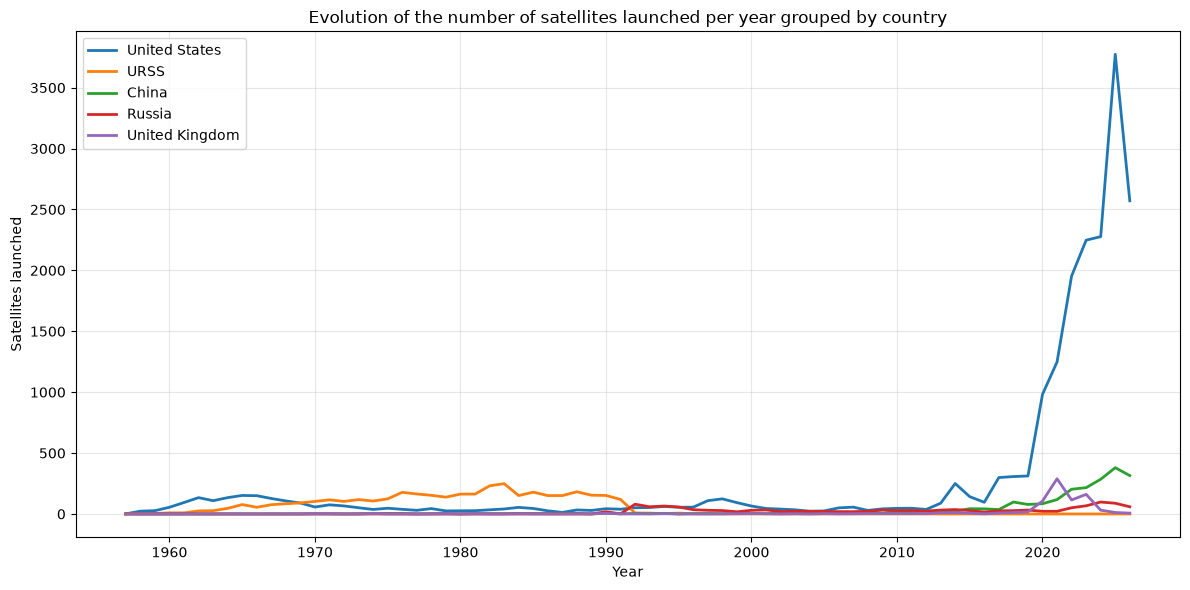

In [127]:
top5_codes = country_counts.head(5).index.tolist()

evo = (
    df[df["SatState"].isin(top5_codes)]
    .groupby(["Year", "SatState"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(df["Year"].min(), df["Year"].max() + 1), fill_value=0)
)

plt.figure(figsize=(12, 6))
for c in top5_codes:
    plt.plot(evo.index, evo[c], label=readable_country(c), linewidth=2)

plt.title("Evolution of the number of satellites launched per year grouped by country")
plt.xlabel("Year")
plt.ylabel("Satellites launched")
plt.legend()
plt.tight_layout()
plt.show()


This chart illustrates the evolution of annual satellite launches by country from 1957 to 2026, comparing the top five space-faring entities.

During the Cold War period (1950s–1980s), activity was exclusively dominated by the URSS and the United States, with the URSS maintaining a steady lead that peaked at around 250 satellites per year in the early 1980s before abruptly ending with its dissolution in 1991. Following a period of relative stagnation across all nations from the 1990s through the 2000s where annual launches rarely exceeded 100 per country, the landscape shifted dramatically after 2018. Driven by an exponential surge, the United States completely outpaced all other nations, rising from under 500 launches around 2019 to an all-time peak of nearly 3,800 satellites in 2025. In contrast, China shows a modest but steady upward trajectory starting around 2015 to reach nearly 400 satellites per year by 2025, while Russia, the United Kingdom.

The downturn observed for the all the country in 2026 is due to incomplete data collection for the current year.

## 6. Which launch vehicle is the most used? (sub-question 3)

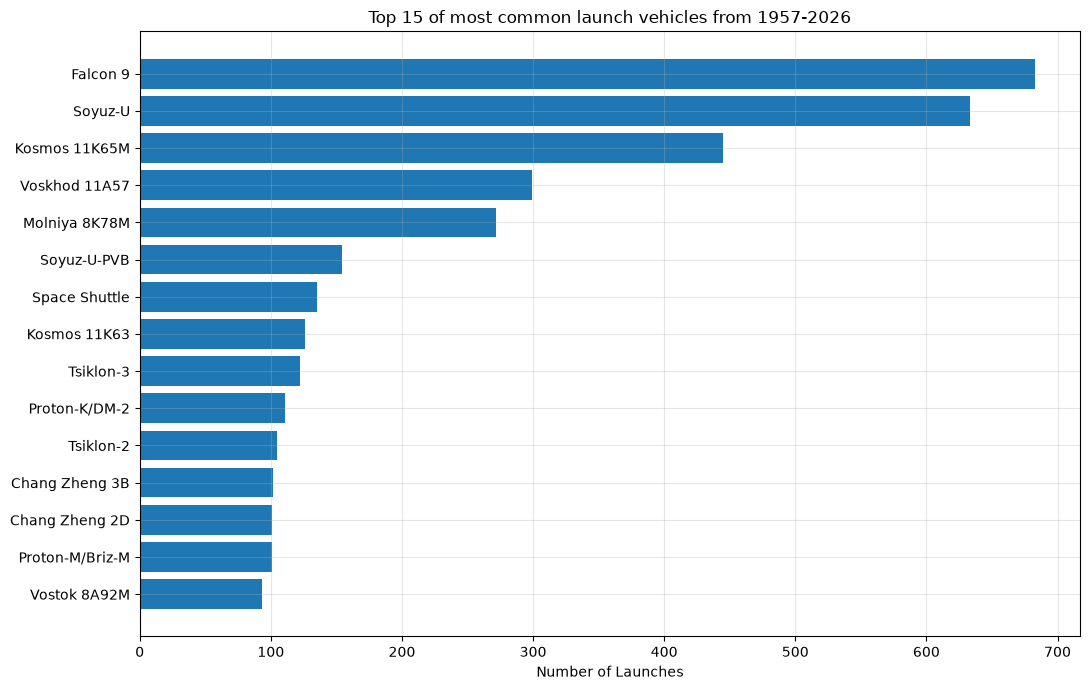

In [128]:
GroupByVehicules = df.drop_duplicates(subset=["Launch_Tag"])[["Launch_Tag", "Year", "LV_Type", "LVState"]]

# print(f"{len(GroupByVehicules):,} lancements distincts")

lv_counts = GroupByVehicules["LV_Type"].value_counts()
top_lv = lv_counts.head(15)

plt.figure(figsize=(11, 7))
plt.barh(top_lv.index[::-1], top_lv.values[::-1])
plt.title("Top 15 of most common launch vehicles from 1957-2026")
plt.xlabel("Number of Launches")
plt.tight_layout()
plt.show()

This horizontal bar chart ranks the top 15 most common space launch vehicles between 1957 and 2026 based on their total number of launches.

The American Falcon 9 leads the ranking as the most utilized rocket, approaching nearly 700 successful launches. It is closely followed by two historic Soviet/Russian launcher: the Soyuz-U in second place with roughly 630 launches, and the Kosmos 11K65M in third place with approximately 440 launches.
The upper-middle tier is composed of the Voskhod 11A57 and Molniya 8K78M, reaching around 300 and 270 launches respectively, followed by the Soyuz-U-PVB and the Space Shuttle hovering between 130 and 150 launches. The lower half of the ranking consists of a tightly clustered group—including various configurations of the Kosmos, Tsiklon, Proton, and Chinese Chang Zheng families all ranging closely between 90 and 125 launches. Overall, the distribution shows a strong concentration at the top, where the top two launch vehicles alone account for a significantly higher volume of missions than the rest of the fleet combined.

Overall, while the top spot belongs to a modern American vehicle (Falcon 9), the distribution highlights a historic duopoly between the United States and the Soviet Union/Russia, which together account for 13 of the 15 most used launch systems in spaceflight history.

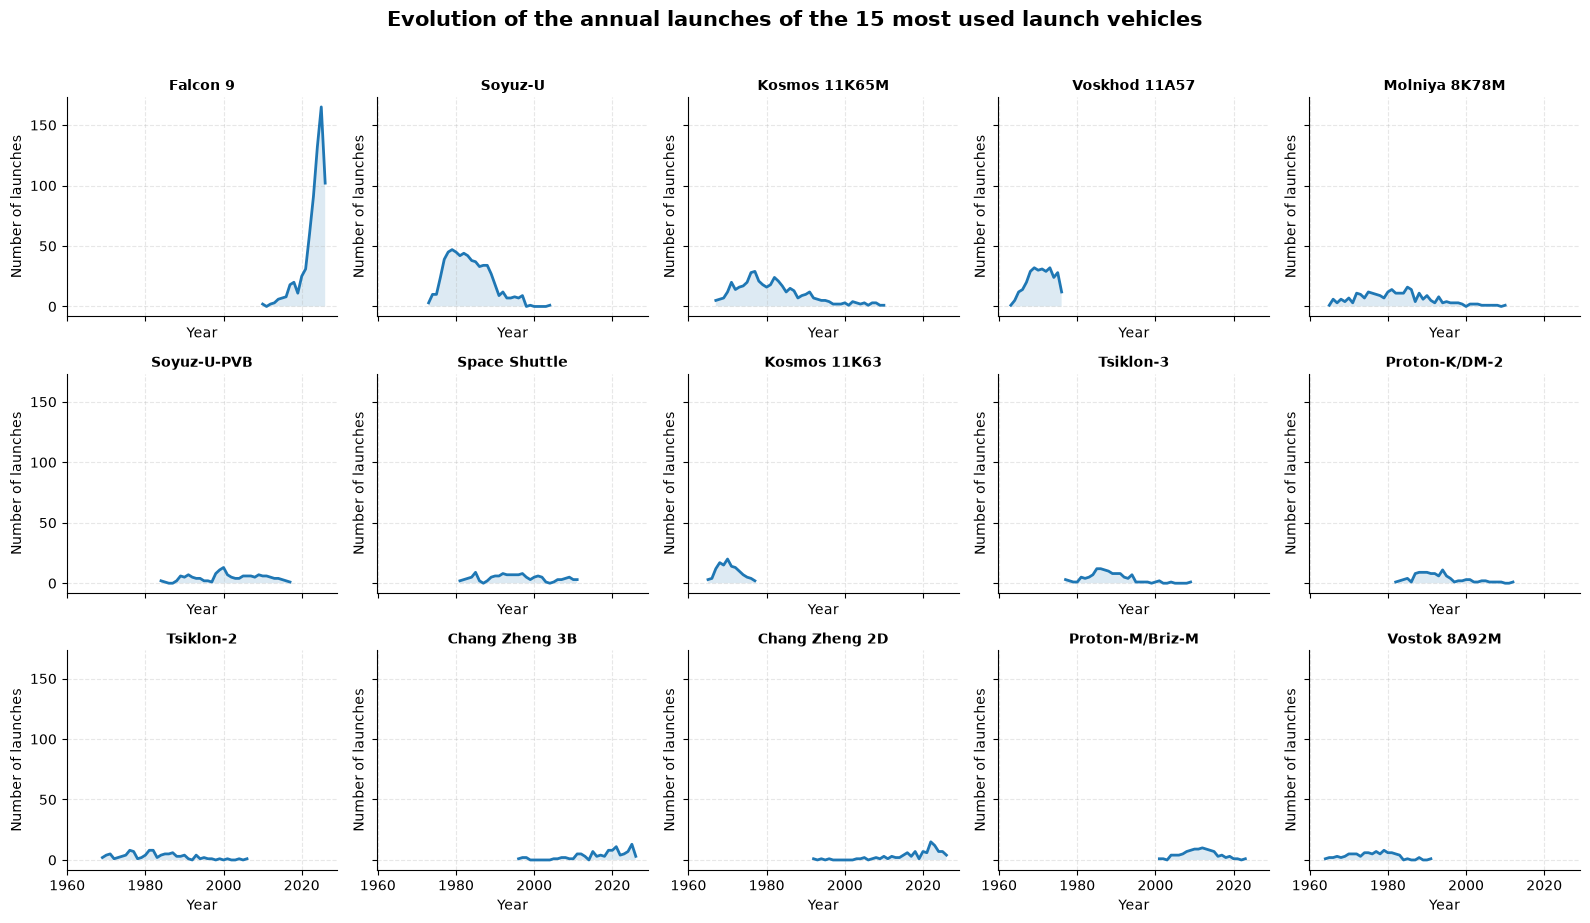

In [129]:
launches = df.drop_duplicates(subset=["Launch_Tag"])[
    ["Launch_Tag", "Year", "LV_Type", "LVState"]
]
top15_lv = lv_counts.head(15).index.tolist()

evo_lv = (
    launches[launches["LV_Type"].isin(top15_lv)]
    .groupby(["Year", "LV_Type"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(launches["Year"].min(), launches["Year"].max() + 1), fill_value=0)
)

# small loop to set Nan for inactive periods
# eg if there is 10 launch in 2011 no launch in 2012 and 2 launch in 2013, the 2012 will be set to 
# Nan in order to show on the graph that it's not a launcher that will be never used again
for lv in evo_lv.columns:
    active_years = evo_lv[evo_lv[lv] > 0].index
    if not active_years.empty:
        first_year = active_years.min()
        last_year = active_years.max()
        
        evo_lv.loc[:first_year - 1, lv] = np.nan
        evo_lv.loc[last_year + 1:, lv] = np.nan

fig, axes = plt.subplots(3, 5, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i, lv in enumerate(top15_lv):
    ax = axes[i]
    
    ax.plot(evo_lv.index, evo_lv[lv], linewidth=2)
    ax.fill_between(
        evo_lv.index, 
        evo_lv[lv], 
        alpha=0.15, 
        where=evo_lv[lv].notna()
    )

    ax.set_title(lv, fontsize=10, fontweight="bold", pad=5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of launches")

fig.suptitle("Evolution of the annual launches of the 15 most used launch vehicles", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()



This mgrid of charts illustrates the annual launch trajectory for each of the top 15 most used launch vehicles over their respective operational lifespans. The grid clearly highlights a stark contrast in launch dynamics across spaceflight history. Legendary Soviet workhorses, such as the Soyuz-U, Kosmos 11K65M, Voskhod 11A57, and Molniya 8K78M, show sustained, moderate activity concentrated between the 1960s and 1990s, peaking around 30 to 50 launches per year before being gradually retired. Similarly, American vehicles like the Space Shuttle maintain a remarkably low and steady rate, rarely exceeding 10 launches per year throughout its operational era from 1981 to 2011.

Conversely, the modern American Falcon 9 displays an unprecedented vertical surge post-2015, dwarfing all historical rocket utilization rates by climbing rapidly to an all-time peak of over 150 launches per year. Meanwhile, active contemporary systems like China's Chang Zheng 3B and 2D show a steady, ongoing rise in recent years, though operating at much more modest annual volumes below 20 launches per year. Overall, the chart demonstrates a fundamental generational shift from long-lived, moderate-cadence historical fleets to an era dominated by a single high-frequency reusable launch system.

# Answer to the question :
Since the dawn of the space age in 1957, global space activity has transformed from a state-driven rivalry into an unprecedented commercial boom.
During the Cold War era (1960s to 1980s), space access was defined by a steady geopolitical race between the United States and the Soviet Union, characterized by a moderate cadence of 100 to 300 annual launches carried out by reliable national workhorses like the Soviet Soyuz and Kosmos families.

Following a period of relative stagnation in the 1990s and 2000s, space activity underwent a massive paradigm shift around 2015 to 2020. Driven by satellite miniaturization, the deployment of mega-constellations like Starlink or OneWeb, and the rise of private space companies, annual satellite launches exploded exponentially to reach a peak of nearly 4,600 satellites per year, pushing the cumulative total beyond 30,000.

While China has steadily expanded its presence in recent years, the overall landscape remains defined by an extreme concentration of power where the United States accounts for nearly two-thirds (63.4%) of all satellites ever orbited largely due to SpaceX's reusable Falcon 9, which dwarfed all historic rocket utilization rates to become the most frequently used launch vehicle in spaceflight history.